## Import packages

In [1]:
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
from io import StringIO
import seaborn as sns
from matplotlib.ticker import MaxNLocator

c:\Users\Administrator\anaconda3\envs\cwir_analysis_env\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


## Generate Experiment Trials

#### Define the number of experiment trials and parameters

In [2]:
n_trials = 60

deadlines = [6,8,10]

#### Helper functions

In [3]:
def generate_combinations():
    """Function to generate all possible lotteries

    Returns:
        _type_: _description_
    """
    
    combinations = []
    
    #The first element is the value which can go from 1 to 100
    for i in range(1,100):  # First element: 1 to 99
        # The second element is the probability (in percentage) and can be anything beetween 1 and 100,
        for j in range(1,100): 
            
            #Calculate the expected value
            EV = i * (j/100)
            
            combinations.append([i,j,EV])
                
    sorted_combinations = sorted(combinations, key=lambda x: x[2])  # Sort by EV
    
    return sorted_combinations


all_combinations = generate_combinations()


def VisualizeGamble(lot_0_val, lot_0_prob, lot_1_val, lot_1_prob):
    """Function to visualize gambles
    """
    
    fig, ax = plt.subplots()

    # Define square properties
    square_size = 4  # Size of each square

    # Create two squares
    for i in range(2):
        x = i * (square_size + 2)  # Adjust spacing between squares to 2 units
        y = 0
        square = plt.Rectangle((x, y), square_size, square_size, fill=False, color='black')
        ax.add_patch(square)
        
        # Determine which lot values to use
        if i == 0:
            val = lot_0_val
            prob = lot_0_prob
        elif i == 1:
            val = lot_1_val
            prob = lot_1_prob
        
        # Position the text in the center of each square
        ax.text(x + square_size / 2, y + square_size / 2 - 1, f'{int(val)}$', fontsize=40, ha='center', va='center')
        ax.text(x + square_size / 2, y + square_size / 2 + 1, f'{int(prob)}%', fontsize=40, ha='center', va='center')

    # Set axis limits and labels
    ax.set_xlim(-0.2, 2 * (square_size + 2))
    ax.set_ylim(-0.2, square_size)
    ax.axis('off')

    # Display the plot
    plt.show()

In [5]:
def generate_trials_from_bounds_uniform(
    n_trials,
    dx_bounds,
    dp_bounds,
    random_state=None,
    shuffle_rows=True,
    replace_within_cell=True,
    min_cell_distance=None,
    distance_metric="euclidean",
    strict_min_cell_distance=False,
):
    """
    Generate gamble pairs with dX and dP constrained to given bounds,
    while making the sample as uniformly distributed over the allowed
    (dX, dP) cells as possible.

    Parameters
    ----------
    n_trials : int
        Number of trials to generate.

    dx_bounds : tuple (dx_min, dx_max)
        Bounds for dX. Since lot_1 must have higher value than lot_0,
        valid dX values are integers in [-98, -1].

    dp_bounds : tuple (dp_min, dp_max)
        Bounds for dP. Since lot_1 must have lower probability than lot_0,
        valid dP values are integers in [1, 98].

    random_state : int or None
        Random seed.

    shuffle_rows : bool
        Whether to shuffle the final rows.

    replace_within_cell : bool
        If False, do not repeat the exact same gamble pair within the same
        (dX, dP) cell. If True, allow repeats.

    min_cell_distance : float or None
        Optional minimum distance between selected (dX, dP) cells when
        n_trials does not exceed the number of available cells.

    distance_metric : {"euclidean", "manhattan", "chebyshev"}
        Distance metric used for min_cell_distance.

    strict_min_cell_distance : bool
        If True, raise an error when the requested spacing cannot be
        satisfied. If False, fall back to the farthest remaining cells.

    Returns
    -------
    grid_gambles : np.ndarray, shape (n_trials, 10)
    d_x_grid : np.ndarray
    d_p_grid : np.ndarray
    d_ev_grid : np.ndarray
    """

    rng = np.random.default_rng(random_state)

    if distance_metric not in {"euclidean", "manhattan", "chebyshev"}:
        raise ValueError(
            "distance_metric must be 'euclidean', 'manhattan', or 'chebyshev'."
        )

    # -------------------------
    # 1) Clean and validate bounds
    # -------------------------
    dx_min, dx_max = sorted(dx_bounds)
    dp_min, dp_max = sorted(dp_bounds)

    # Clamp to feasible ranges
    dx_min = max(dx_min, -98)
    dx_max = min(dx_max, -1)
    dp_min = max(dp_min, 1)
    dp_max = min(dp_max, 98)

    # dX and dP are integer-valued by construction
    dx_values = np.arange(int(np.ceil(dx_min)), int(np.floor(dx_max)) + 1)
    dp_values = np.arange(int(np.ceil(dp_min)), int(np.floor(dp_max)) + 1)

    if len(dx_values) == 0:
        raise ValueError("No feasible integer dX values in the requested bounds.")
    if len(dp_values) == 0:
        raise ValueError("No feasible integer dP values in the requested bounds.")

    # All allowed (dX, dP) cells
    cells = [(dx, dp) for dx in dx_values for dp in dp_values]
    n_cells = len(cells)
    cells_array = np.array(cells, dtype=float)

    def _distance_to_point(point):
        deltas = np.abs(cells_array - point)
        if distance_metric == "euclidean":
            return np.sqrt(np.sum(deltas ** 2, axis=1))
        if distance_metric == "manhattan":
            return np.sum(deltas, axis=1)
        return np.max(deltas, axis=1)

    def _select_spread_out_cells(n_select):
        if n_select == 0:
            return []

        chosen_mask = np.zeros(n_cells, dtype=bool)
        first_idx = int(rng.integers(n_cells))
        chosen_idx = [first_idx]
        chosen_mask[first_idx] = True

        min_distances = _distance_to_point(cells_array[first_idx])
        min_distances[chosen_mask] = -np.inf

        while len(chosen_idx) < n_select:
            available = ~chosen_mask
            valid = available

            if min_cell_distance is not None:
                valid = available & (min_distances >= min_cell_distance)

            if not np.any(valid):
                if strict_min_cell_distance and min_cell_distance is not None:
                    raise ValueError(
                        f"Could not place {n_select} cells with "
                        f"min_cell_distance={min_cell_distance}."
                    )
                valid = available

            best_distance = np.max(min_distances[valid])
            candidate_idx = np.flatnonzero(
                valid & np.isclose(min_distances, best_distance)
            )
            next_idx = int(rng.choice(candidate_idx))
            chosen_idx.append(next_idx)
            chosen_mask[next_idx] = True
            min_distances = np.minimum(
                min_distances,
                _distance_to_point(cells_array[next_idx])
            )
            min_distances[chosen_mask] = -np.inf

        return [cells[idx] for idx in chosen_idx]

    # -------------------------
    # 2) Allocate trials across cells as uniformly as possible
    # -------------------------
    if min_cell_distance is not None and n_trials > n_cells:
        raise ValueError(
            "min_cell_distance is only supported when n_trials does not exceed "
            "the number of available (dX, dP) cells."
        )

    if min_cell_distance is not None:
        selected_cells = _select_spread_out_cells(n_trials)
        cell_counts = {cell: 0 for cell in cells}
        for cell in selected_cells:
            cell_counts[cell] += 1
    else:
        base = n_trials // n_cells
        remainder = n_trials % n_cells

        cell_counts = {cell: base for cell in cells}

        if remainder > 0:
            extra_cells_idx = rng.choice(n_cells, size=remainder, replace=False)
            for idx in extra_cells_idx:
                cell_counts[cells[idx]] += 1

    # Optional capacity check if exact duplicate pairs are not allowed
    if not replace_within_cell:
        total_capacity = 0
        for dx, dp in cells:
            n_x0 = 99 + dx
            n_p0 = 99 - dp
            total_capacity += n_x0 * n_p0

        if n_trials > total_capacity:
            raise ValueError(
                "Requested more unique trials than exist inside these bounds. "
                "Set replace_within_cell=True or reduce n_trials."
            )

    # -------------------------
    # 3) Sample actual gamble pairs inside each (dX, dP) cell
    # -------------------------
    rows = []

    for dx, dp in cells:
        n_here = cell_counts[(dx, dp)]
        if n_here == 0:
            continue

        # Feasible lot_0 ranges:
        # x1 = x0 - dx must stay <= 99
        # p1 = p0 - dp must stay >= 1
        n_x0 = 99 + dx
        n_p0 = 99 - dp

        capacity = n_x0 * n_p0

        if (not replace_within_cell) and (n_here > capacity):
            raise ValueError(
                f"Cell (dX={dx}, dP={dp}) only has {capacity} unique gamble pairs, "
                f"but {n_here} were requested."
            )

        if replace_within_cell:
            flat_idx = rng.integers(0, capacity, size=n_here)
        else:
            flat_idx = rng.choice(capacity, size=n_here, replace=False)

        # Decode flat indices into x0 and p0
        # x0 in [1, 99+dx]
        # p0 in [1+dp, 99]
        x0 = 1 + (flat_idx // n_p0)
        p0 = 1 + dp + (flat_idx % n_p0)

        x1 = x0 - dx
        p1 = p0 - dp

        ev0 = x0 * (p0 / 100.0)
        ev1 = x1 * (p1 / 100.0)
        dEV = ev0 - ev1

        for a, b, c, d, e, f, g in zip(x0, p0, ev0, x1, p1, ev1, dEV):
            rows.append([0, a, b, c, d, e, f, dx, dp, g])

    # -------------------------
    # 4) Convert to array and shuffle
    # -------------------------
    grid_gambles = np.array(rows, dtype=float)

    if len(grid_gambles) != n_trials:
        raise RuntimeError("Internal error: generated wrong number of trials.")

    if shuffle_rows:
        rng.shuffle(grid_gambles)

    # Re-number GambleNumber after shuffling
    grid_gambles[:, 0] = np.arange(1, n_trials + 1)

    d_x_grid = grid_gambles[:, 7].copy()
    d_p_grid = grid_gambles[:, 8].copy()
    d_ev_grid = grid_gambles[:, 9].copy()

    return grid_gambles, d_x_grid, d_p_grid, d_ev_grid


In [6]:
def assign_deadlines_minimize_hist_divergence(
    grid_gambles,
    deadlines,
    group_sizes=(33, 33, 33),
    n_bins=8,
    binning="quantile",   # "quantile" or "uniform"
    alpha=0.5,            # smoothing for KL
    objective="user_kl",  # "user_kl", "sym_kl", or "js"
    max_passes=30,
    random_state=42,
):
    """
    Assign deadlines so that the dEV histograms across deadline groups are similar.

    Parameters
    ----------
    grid_gambles : np.ndarray
        Expected columns:
        [GambleNumber, lot_0_val, lot_0_prob, lot_0_ev,
         lot_1_val, lot_1_prob, lot_1_ev, dX, dP, dEV]
    deadlines : length-3 iterable
        Deadline labels, e.g. [6, 8, 10]
    group_sizes : tuple
        Fixed sizes for each deadline group
    n_bins : int
        Number of histogram bins
    binning : str
        "quantile" gives more stable bins when sample is small
    alpha : float
        Smoothing to avoid zero-probability bins
    objective : str
        "user_kl" = KL(0||1) + KL(1||2) + KL(0||2)
        "sym_kl"  = symmetrized KL over pairs (0,1), (1,2), (0,2)
        "js"      = Jensen-Shannon divergence over pairs
    max_passes : int
        Number of greedy improvement passes
    random_state : int
        RNG seed

    Returns
    -------
    df_gambles : pd.DataFrame
    hist_counts_df : pd.DataFrame
    info : dict
        Contains objective value, pairwise divergences, bin edges, etc.
    """

    if len(deadlines) != 3:
        raise ValueError("deadlines must have length 3")
    if sum(group_sizes) != len(grid_gambles):
        raise ValueError("group_sizes must sum to len(grid_gambles)")

    rng = np.random.default_rng(random_state)

    column_names = [
        "GambleNumber",
        "lot_0_val",
        "lot_0_prob",
        "lot_0_ev",
        "lot_1_val",
        "lot_1_prob",
        "lot_1_ev",
        "dX",
        "dP",
        "dEV",
    ]

    df_gambles = pd.DataFrame(grid_gambles, columns=column_names)
    dEV = df_gambles["dEV"].to_numpy(dtype=float)
    n = len(dEV)
    k = 3

    # -----------------------------
    # 1) Build common histogram bins
    # -----------------------------
    if binning == "quantile":
        edges = np.quantile(dEV, np.linspace(0, 1, n_bins + 1))
        edges = np.unique(edges)
        if len(edges) < 3:
            edges = np.linspace(dEV.min(), dEV.max() + 1e-12, n_bins + 1)
    elif binning == "uniform":
        edges = np.linspace(dEV.min(), dEV.max() + 1e-12, n_bins + 1)
    else:
        raise ValueError("binning must be 'quantile' or 'uniform'")

    n_bins_eff = len(edges) - 1
    if n_bins_eff < 2:
        raise ValueError("Could not construct at least 2 histogram bins from dEV")

    # Bin index for each item
    bin_idx = np.digitize(dEV, edges[1:-1], right=False)
    bin_idx = np.clip(bin_idx, 0, n_bins_eff - 1)

    # --------------------------------------------
    # 2) Good initialization: interleave sorted dEV
    # --------------------------------------------
    def make_interleaved_labels(group_sizes, rng):
        remaining = np.array(group_sizes, dtype=int).copy()
        labels = []
        while remaining.sum() > 0:
            for g in rng.permutation(len(group_sizes)):
                if remaining[g] > 0:
                    labels.append(g)
                    remaining[g] -= 1
        return np.array(labels, dtype=int)

    sorted_idx = np.argsort(dEV)
    init_labels = make_interleaved_labels(group_sizes, rng)

    assignments = np.empty(n, dtype=int)
    assignments[sorted_idx] = init_labels

    # -----------------------------
    # 3) Histogram count utilities
    # -----------------------------
    def build_counts(assignments):
        counts = np.zeros((k, n_bins_eff), dtype=int)
        for i, g in enumerate(assignments):
            counts[g, bin_idx[i]] += 1
        return counts

    counts = build_counts(assignments)

    def probs(count_row, group_size):
        return (count_row + alpha) / (group_size + alpha * len(count_row))

    def kl(p, q):
        return np.sum(p * np.log(p / q))

    def js(p, q):
        m = 0.5 * (p + q)
        return 0.5 * kl(p, m) + 0.5 * kl(q, m)

    def pairwise_divergences(counts):
        p0 = probs(counts[0], group_sizes[0])
        p1 = probs(counts[1], group_sizes[1])
        p2 = probs(counts[2], group_sizes[2])

        out = {
            "KL_0_1": kl(p0, p1),
            "KL_1_2": kl(p1, p2),
            "KL_0_2": kl(p0, p2),
            "SKL_0_1": kl(p0, p1) + kl(p1, p0),
            "SKL_1_2": kl(p1, p2) + kl(p2, p1),
            "SKL_0_2": kl(p0, p2) + kl(p2, p0),
            "JS_0_1": js(p0, p1),
            "JS_1_2": js(p1, p2),
            "JS_0_2": js(p0, p2),
        }
        return out

    def objective_value(counts):
        divs = pairwise_divergences(counts)

        if objective == "user_kl":
            # exactly what you described:
            # KL(deadline0 || deadline1) + KL(deadline1 || deadline2) + KL(deadline0 || deadline2)
            return divs["KL_0_1"] + divs["KL_1_2"] + divs["KL_0_2"]

        elif objective == "sym_kl":
            return divs["SKL_0_1"] + divs["SKL_1_2"] + divs["SKL_0_2"]

        elif objective == "js":
            return divs["JS_0_1"] + divs["JS_1_2"] + divs["JS_0_2"]

        else:
            raise ValueError("objective must be 'user_kl', 'sym_kl', or 'js'")

    best_obj = objective_value(counts)

    # ---------------------------------
    # 4) Greedy pair-swap local search
    # ---------------------------------
    for _ in range(max_passes):
        improved = False
        best_swap = None
        best_swap_obj = best_obj

        group_members = [np.where(assignments == g)[0] for g in range(k)]

        for g1 in range(k):
            for g2 in range(g1 + 1, k):
                idx1 = group_members[g1]
                idx2 = group_members[g2]

                for i in idx1:
                    b1 = bin_idx[i]
                    for j in idx2:
                        b2 = bin_idx[j]

                        # Swapping items in the same bin does not change the histogram objective
                        if b1 == b2:
                            continue

                        trial_counts = counts.copy()

                        # remove i from g1/bin b1, add j to g1/bin b2
                        trial_counts[g1, b1] -= 1
                        trial_counts[g1, b2] += 1

                        # remove j from g2/bin b2, add i to g2/bin b1
                        trial_counts[g2, b2] -= 1
                        trial_counts[g2, b1] += 1

                        trial_obj = objective_value(trial_counts)

                        if trial_obj < best_swap_obj - 1e-12:
                            best_swap_obj = trial_obj
                            best_swap = (i, j, g1, g2, trial_counts)

        if best_swap is None:
            break

        i, j, g1, g2, counts = best_swap
        assignments[i], assignments[j] = assignments[j], assignments[i]
        best_obj = best_swap_obj
        improved = True

        if not improved:
            break

    # -----------------------------
    # 5) Build final dataframe
    # -----------------------------
    deadline_array = np.array([deadlines[g] for g in assignments], dtype=object)
    df_gambles["Deadline"] = deadline_array
    df_gambles["dEV_bin"] = bin_idx

    hist_counts_df = (
        pd.crosstab(df_gambles["Deadline"], df_gambles["dEV_bin"])
        .reindex(index=deadlines, fill_value=0)
    )

    info = {
        "objective": objective,
        "objective_value": best_obj,
        "pairwise_divergences": pairwise_divergences(counts),
        "bin_edges": edges,
        "n_bins_effective": n_bins_eff,
        "group_sizes": group_sizes,
        "mean_dEV_by_deadline": df_gambles.groupby("Deadline")["dEV"].mean().reindex(deadlines),
    }

    return df_gambles, hist_counts_df, info

#### Generate trials from grid criteria

In [35]:
grid_gambles, d_x_grid, d_p_grid, d_ev_grid = generate_trials_from_bounds_uniform(
    n_trials=60,
    dx_bounds=(-30, 0),
    dp_bounds=(0, 30),
    random_state=random.randint(1, 1000),
    min_cell_distance=5,
)

#### Add deadlines

In [36]:
df_gambles, hist_counts, info = assign_deadlines_minimize_hist_divergence(
    grid_gambles,
    deadlines,
    group_sizes=(20, 20, 20),
    n_bins=8,
    binning="quantile",
    alpha=0.5,
    objective="sym_kl",
    max_passes=300000,
    random_state=random.randint(1, 1000),
)


## Analyze Experiment Trials

#### Check dX, dP and dEV distributions

dEV summary statistics:
6-second deadline:  mean dEV = 0.059, median dEV = -0.000
8-second deadline:  mean dEV = 0.067, median dEV = 0.245
10-second deadline: mean dEV = 0.086, median dEV = 0.185


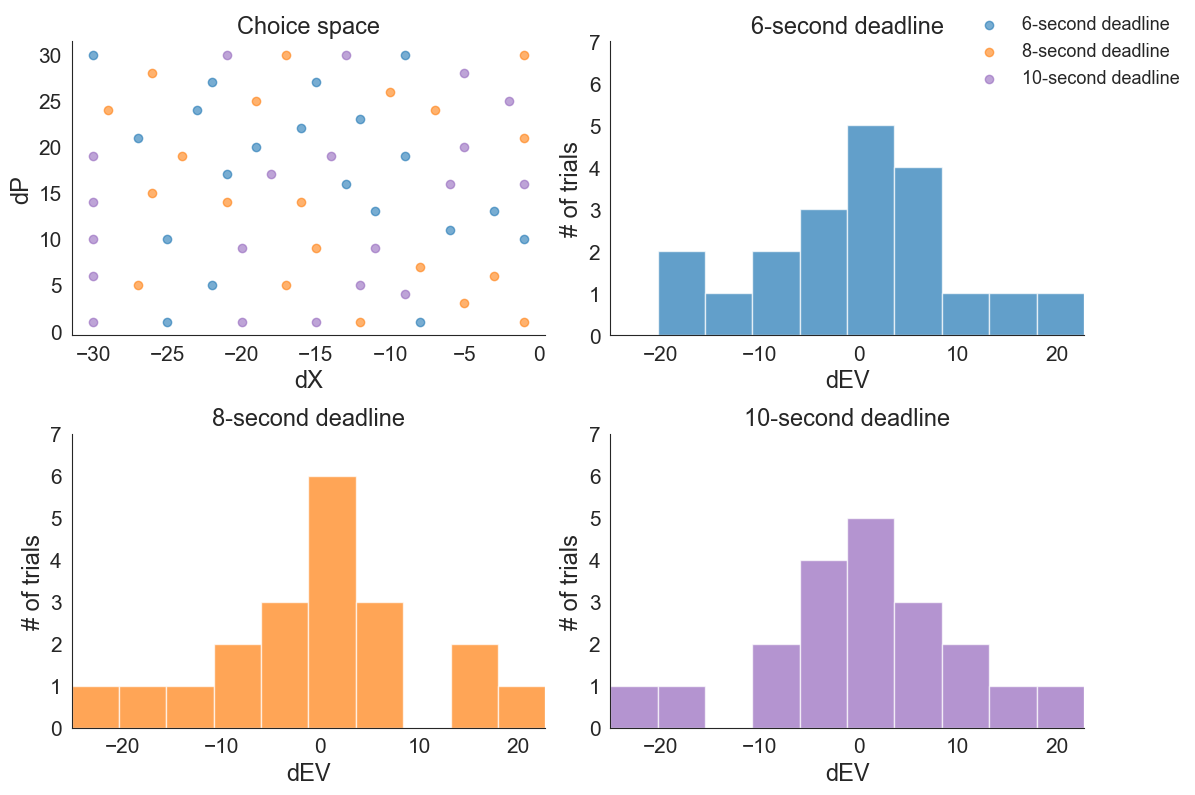

In [37]:
# --- Seaborn style ---
sns.set_style("white")

fontsize = 17

gambles_deadline_6 = df_gambles[df_gambles['Deadline'] == 6]
gambles_deadline_8 = df_gambles[df_gambles['Deadline'] == 8]
gambles_deadline_10 = df_gambles[df_gambles['Deadline'] == 10]

# --- Define colors from Matplotlib's default palette ---
colors = ["C0", "C1", "C4"]

# --- Collect all dEV values for common histogram settings ---
dev_6 = gambles_deadline_6['dEV'].dropna()
dev_8 = gambles_deadline_8['dEV'].dropna()
dev_10 = gambles_deadline_10['dEV'].dropna()

all_dev = np.concatenate([dev_6, dev_8, dev_10])

# Common bins and x-limits
bins = np.histogram_bin_edges(all_dev, bins=10)
x_min, x_max = all_dev.min(), all_dev.max()

# Precompute histogram counts to get a common y-limit
counts_6, _ = np.histogram(dev_6, bins=bins)
counts_8, _ = np.histogram(dev_8, bins=bins)
counts_10, _ = np.histogram(dev_10, bins=bins)
y_max = max(counts_6.max(), counts_8.max(), counts_10.max())

# --- Print summary stats ---
print("dEV summary statistics:")
print(f"6-second deadline:  mean dEV = {dev_6.mean():.3f}, median dEV = {dev_6.median():.3f}")
print(f"8-second deadline:  mean dEV = {dev_8.mean():.3f}, median dEV = {dev_8.median():.3f}")
print(f"10-second deadline: mean dEV = {dev_10.mean():.3f}, median dEV = {dev_10.median():.3f}")

# --- Create figure: 2 x 2 layout ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# =========================
# Top-left: scatter plot
# =========================
axes[0, 0].scatter(
    gambles_deadline_6['dX'], gambles_deadline_6['dP'],
    color=colors[0], alpha=0.6, label='6-second deadline'
)
axes[0, 0].scatter(
    gambles_deadline_8['dX'], gambles_deadline_8['dP'],
    color=colors[1], alpha=0.6, label='8-second deadline'
)
axes[0, 0].scatter(
    gambles_deadline_10['dX'], gambles_deadline_10['dP'],
    color=colors[2], alpha=0.6, label='10-second deadline'
)

axes[0, 0].set_xlabel("dX", fontsize=fontsize)
axes[0, 0].set_ylabel("dP", fontsize=fontsize)
axes[0, 0].set_title("Choice space", fontsize=fontsize)

# =========================
# Top-right: dEV histogram, deadline 6
# =========================
axes[0, 1].hist(dev_6, bins=bins, color=colors[0], alpha=0.7)
axes[0, 1].set_title("6-second deadline", fontsize=fontsize)
axes[0, 1].set_xlabel("dEV", fontsize=fontsize)
axes[0, 1].set_ylabel("# of trials", fontsize=fontsize)
axes[0, 1].set_xlim(x_min, x_max)
axes[0, 1].set_ylim(0, y_max + 1)
axes[0, 1].yaxis.set_major_locator(MaxNLocator(integer=True))

# =========================
# Bottom-left: dEV histogram, deadline 8
# =========================
axes[1, 0].hist(dev_8, bins=bins, color=colors[1], alpha=0.7)
axes[1, 0].set_title("8-second deadline", fontsize=fontsize)
axes[1, 0].set_xlabel("dEV", fontsize=fontsize)
axes[1, 0].set_ylabel("# of trials", fontsize=fontsize)
axes[1, 0].set_xlim(x_min, x_max)
axes[1, 0].set_ylim(0, y_max + 1)
axes[1, 0].yaxis.set_major_locator(MaxNLocator(integer=True))

# =========================
# Bottom-right: dEV histogram, deadline 10
# =========================
axes[1, 1].hist(dev_10, bins=bins, color=colors[2], alpha=0.7)
axes[1, 1].set_title("10-second deadline", fontsize=fontsize)
axes[1, 1].set_xlabel("dEV", fontsize=fontsize)
axes[1, 1].set_ylabel("# of trials", fontsize=fontsize)
axes[1, 1].set_xlim(x_min, x_max)
axes[1, 1].set_ylim(0, y_max + 1)
axes[1, 1].yaxis.set_major_locator(MaxNLocator(integer=True))

# --- Shared legend ---
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=13, frameon=False)

# --- Despine and tick formatting ---
for ax in axes.flat:
    sns.despine(ax=ax, top=True, right=True)
    ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

#### Check gambles in 3D plot

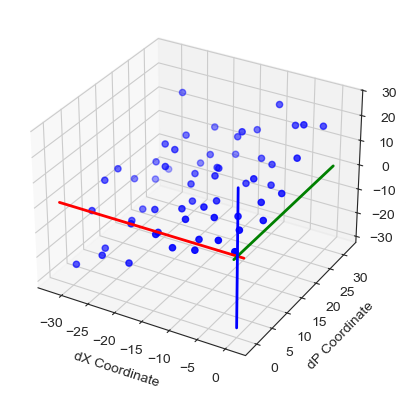

In [38]:
fig = plt.figure()

# Add a 3D subplot
ax = fig.add_subplot(111, projection='3d')

# Plot the scatter plot with x, y, and z coordinates
ax.scatter(d_x_grid, d_p_grid, d_ev_grid, color = "blue")

# Label the axes
ax.set_xlabel('dX Coordinate')
ax.set_ylabel('dP Coordinate')
ax.set_zlabel('dEV Coordinate')

xlim = ax.get_xlim()
ylim = ax.get_ylim()
zlim = ax.get_zlim()


ax.plot([xlim[0], xlim[1]], [0, 0], [0, 0], color='r', linewidth=2, label='dX-axis')

# Draw the y-axis
ax.plot([0, 0], [ylim[0], ylim[1]], [0, 0], color='g', linewidth=2, label='dP-axis')

# Draw the z-axis
ax.plot([0, 0], [0, 0], [zlim[0], zlim[1]], color='b', linewidth=2, label='dEV-axis')


# Display the plot
plt.show()

#### Check gamble dilemma

dEV: -7.68


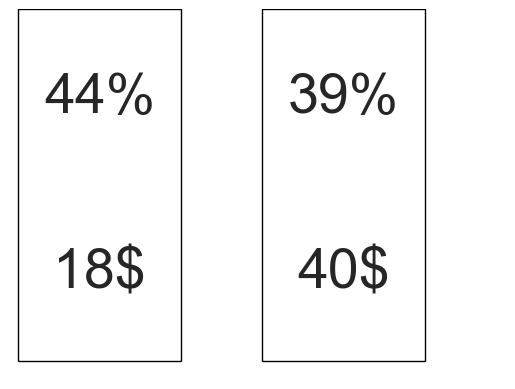

dEV: -7.86


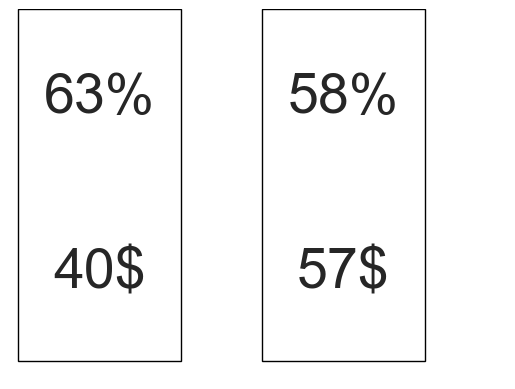

dEV: 7.20


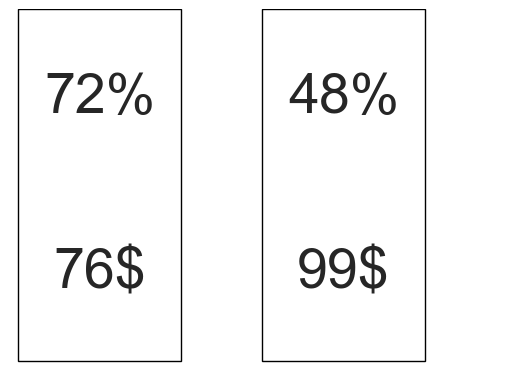

dEV: -0.09


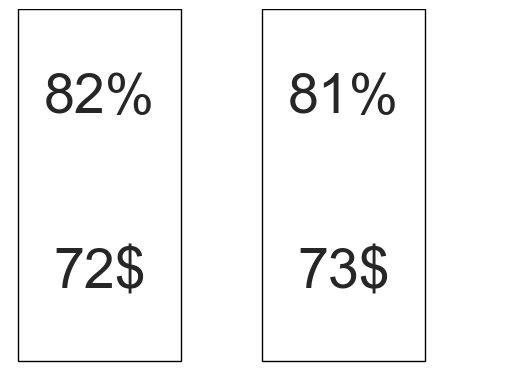

dEV: 18.86


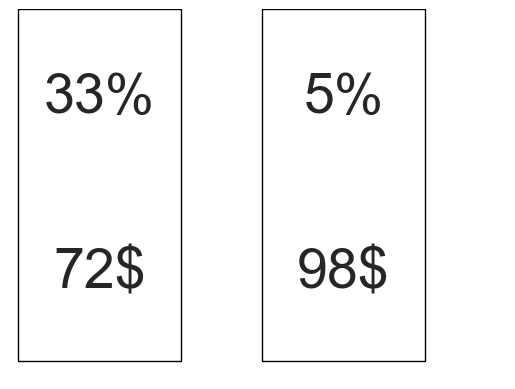

dEV: -0.28


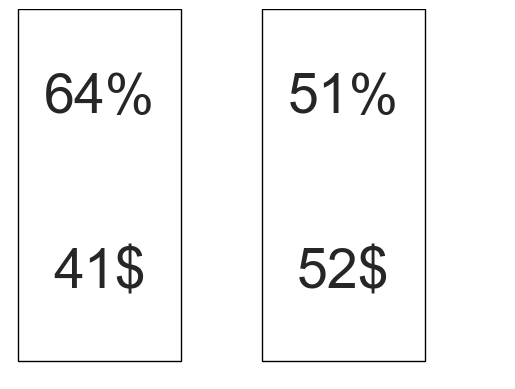

dEV: -4.27


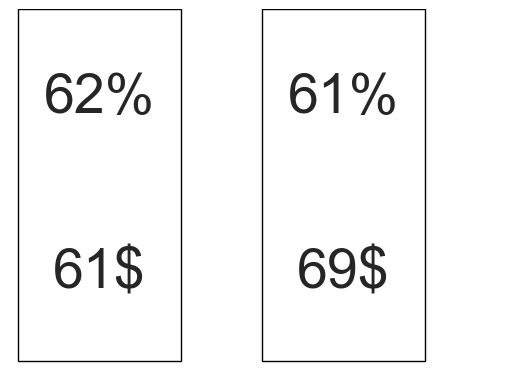

dEV: 8.42


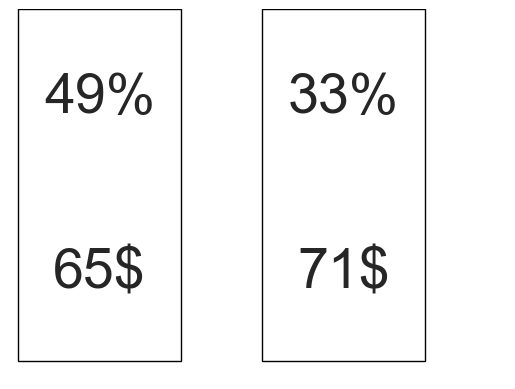

dEV: 5.74


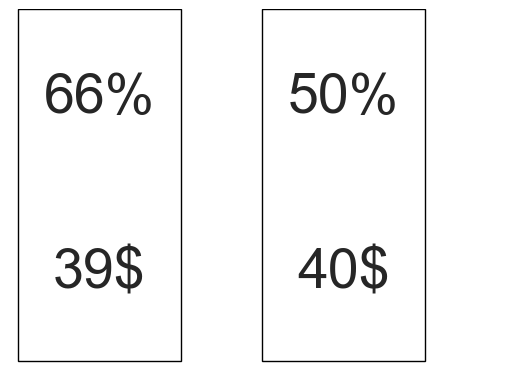

dEV: -9.85


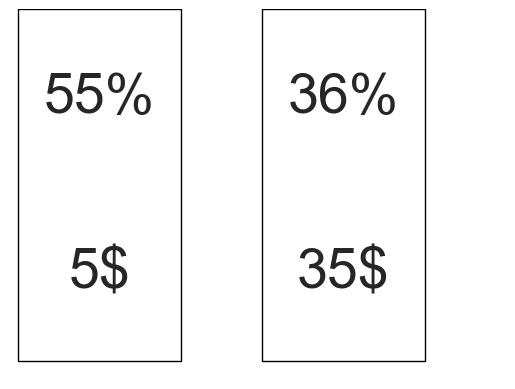

dEV: 4.44


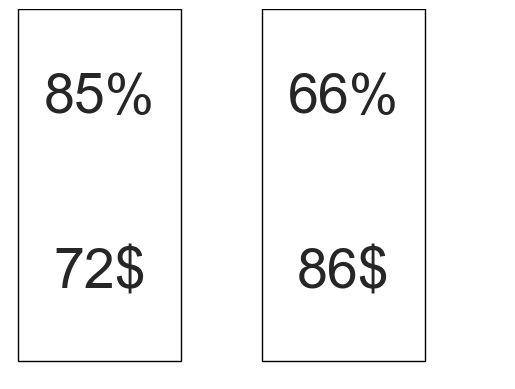

dEV: 14.35


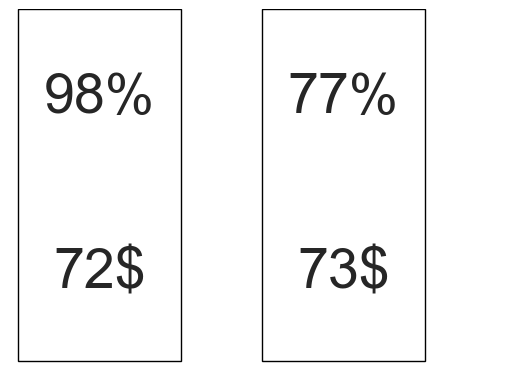

dEV: 1.75


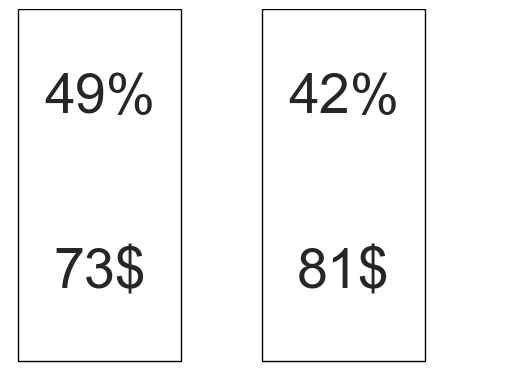

dEV: -2.31


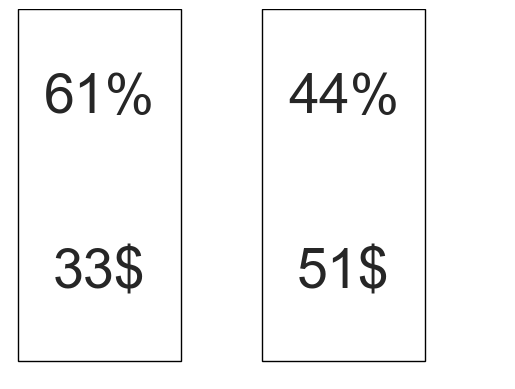

dEV: -4.72


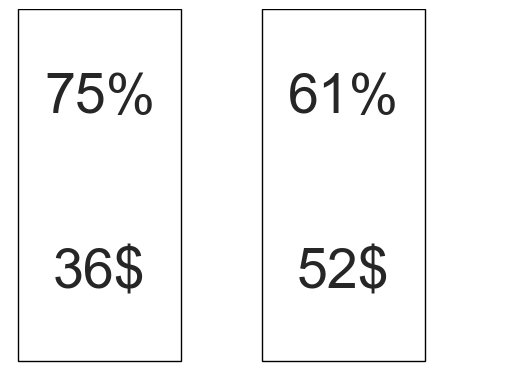

dEV: 1.20


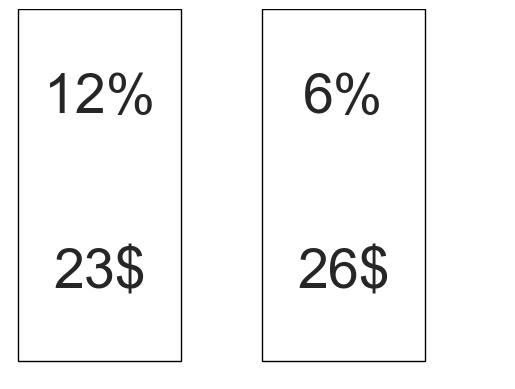

dEV: -1.56


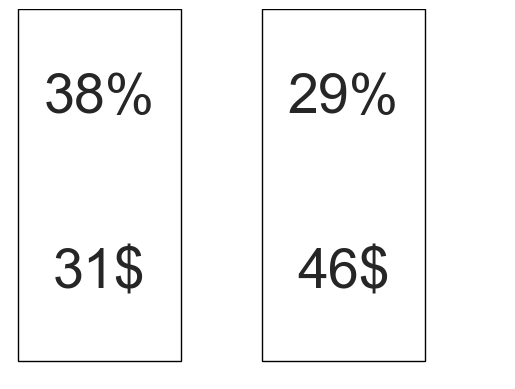

dEV: 21.72


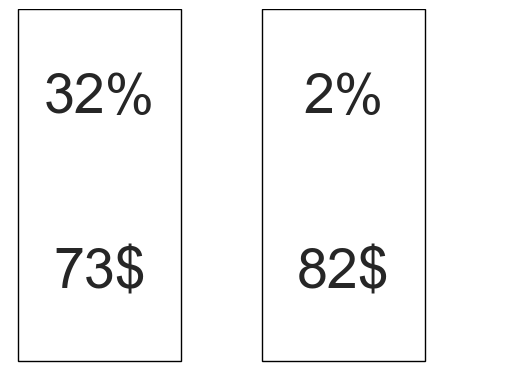

dEV: 1.76


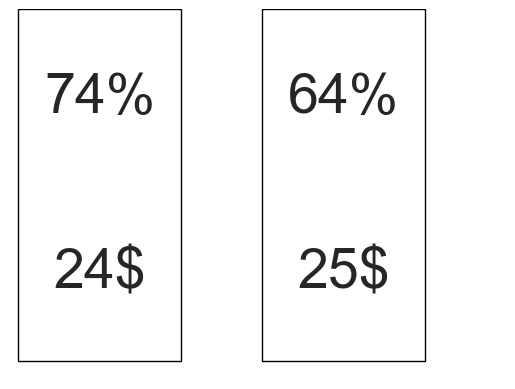

dEV: -0.70


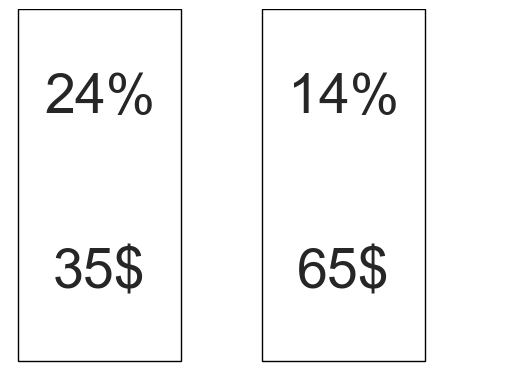

dEV: 3.46


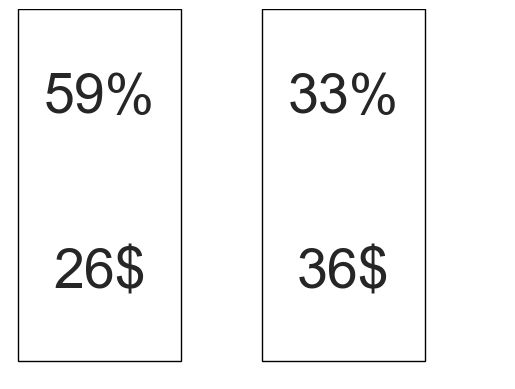

dEV: -14.83


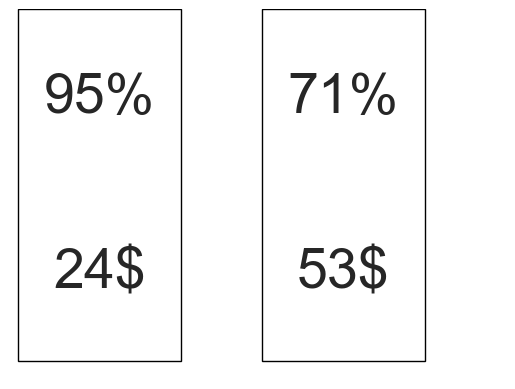

dEV: 1.71


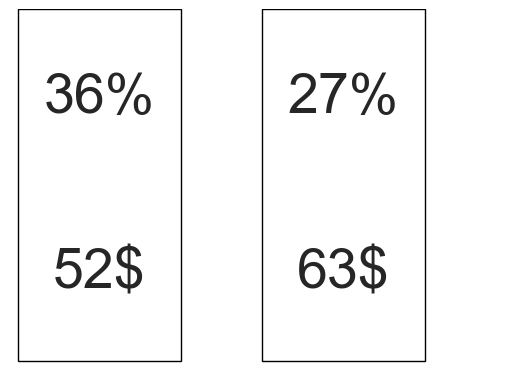

dEV: -17.70


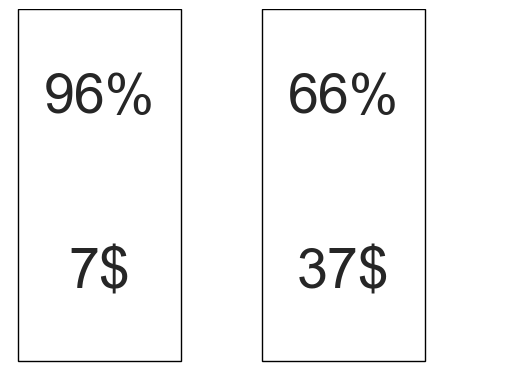

dEV: 4.27


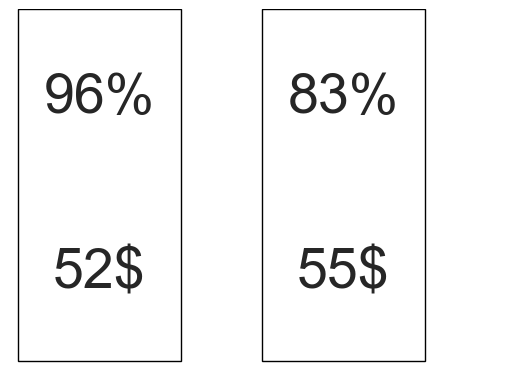

dEV: 22.77


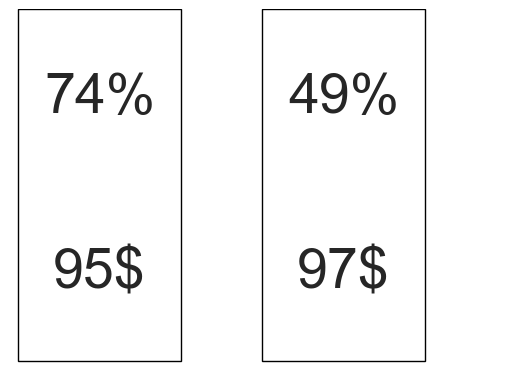

dEV: 2.15


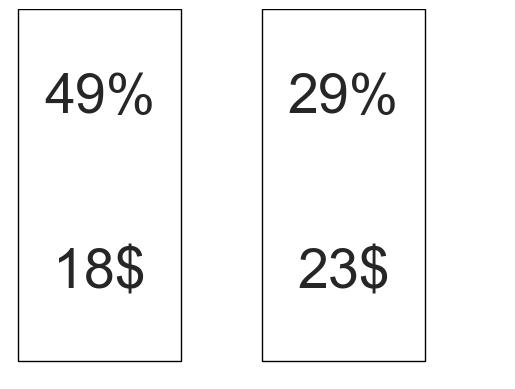

dEV: -6.93


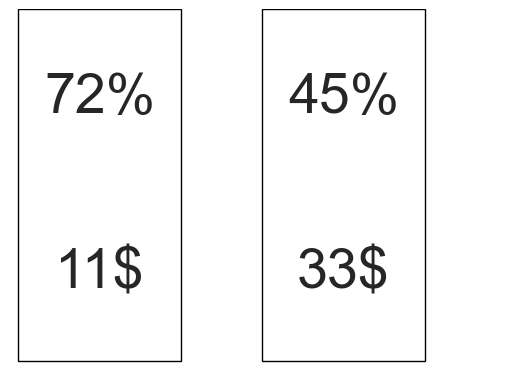

dEV: 17.72


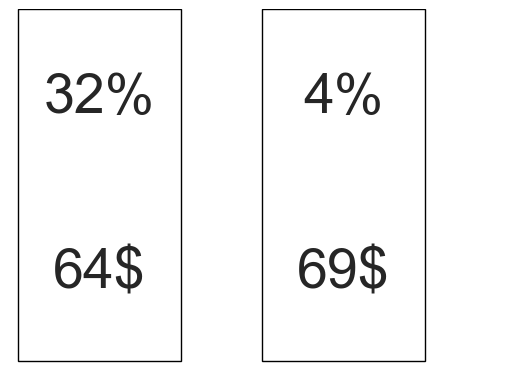

dEV: -4.18


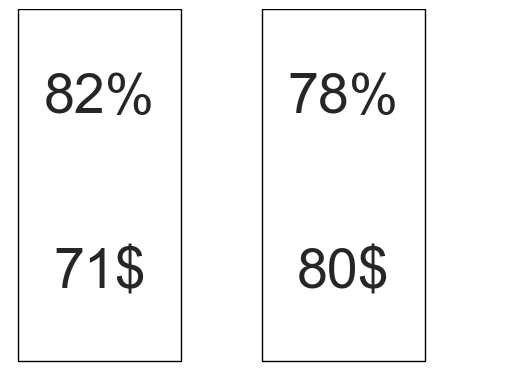

dEV: -2.71


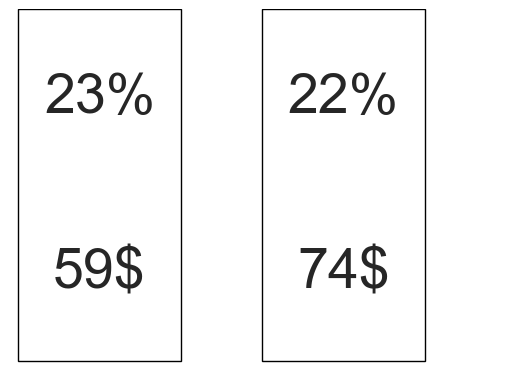

dEV: 17.69


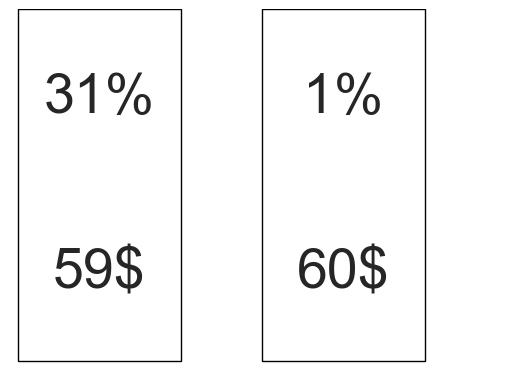

dEV: -0.69


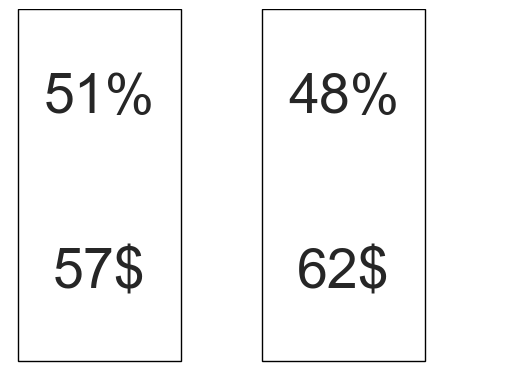

dEV: 1.44


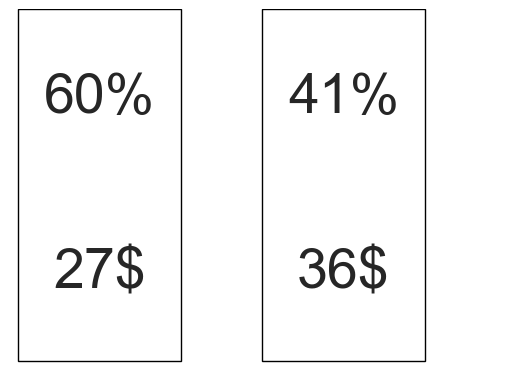

dEV: 8.22


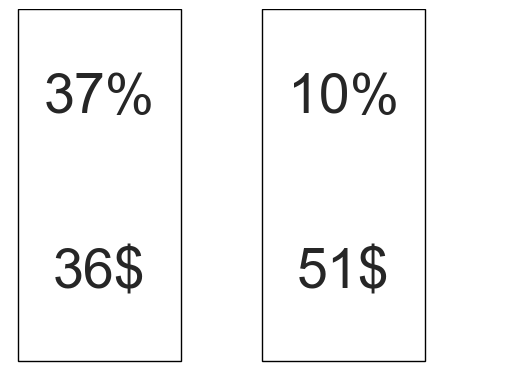

dEV: 9.81


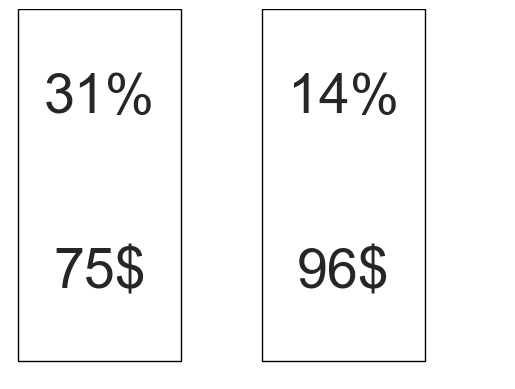

dEV: 5.21


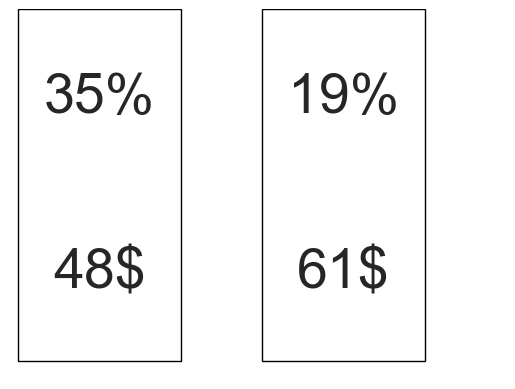

dEV: -5.13


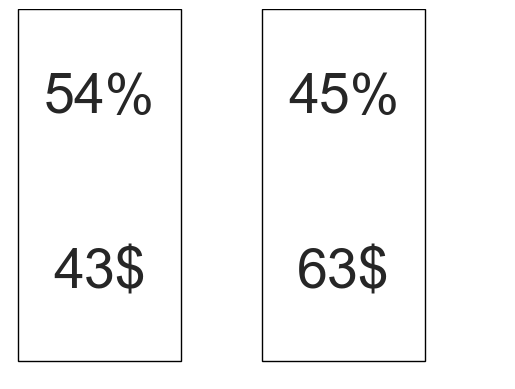

dEV: -1.92


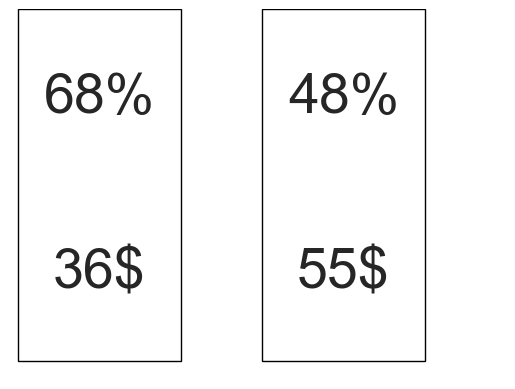

dEV: -8.70


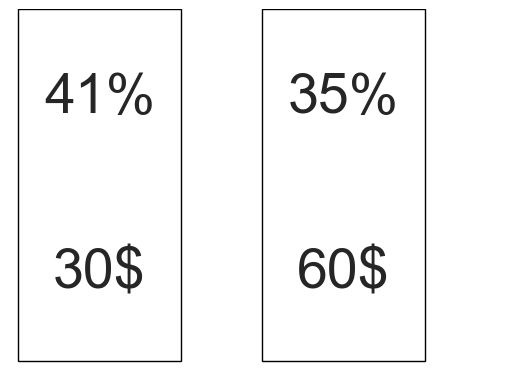

dEV: 9.20


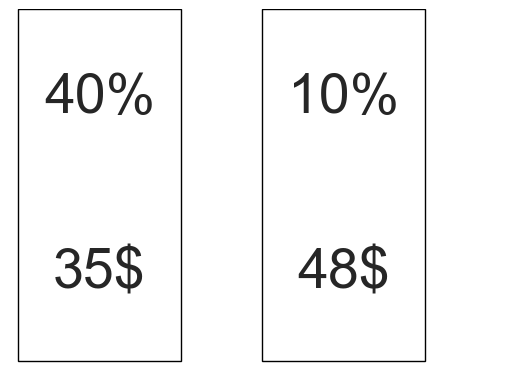

dEV: 0.28


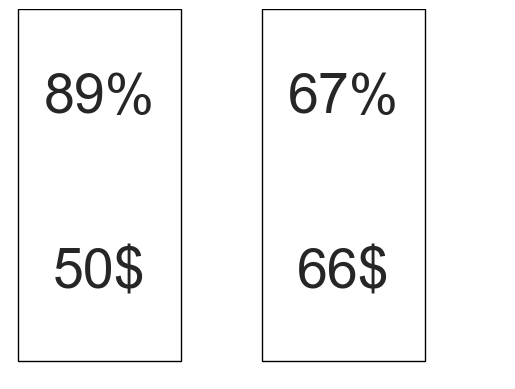

dEV: -14.05


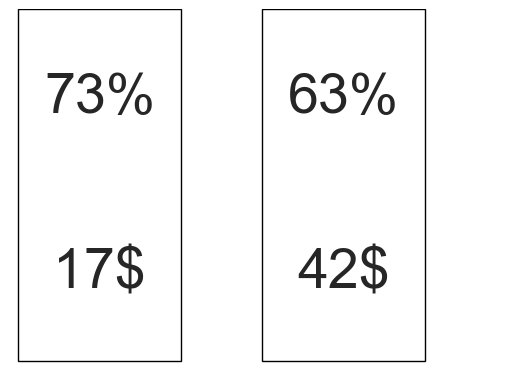

dEV: -15.61


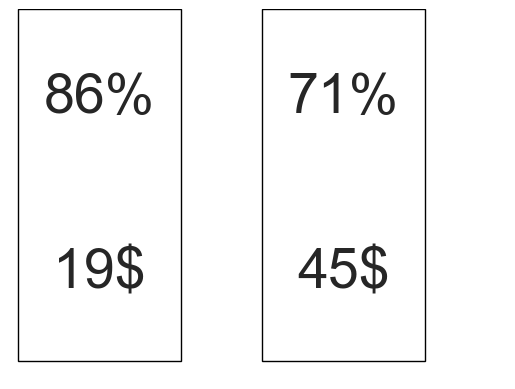

dEV: -17.68


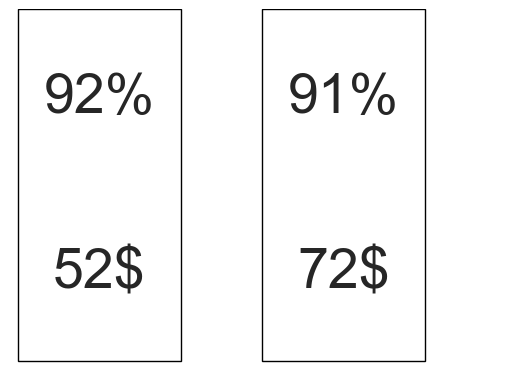

dEV: 16.14


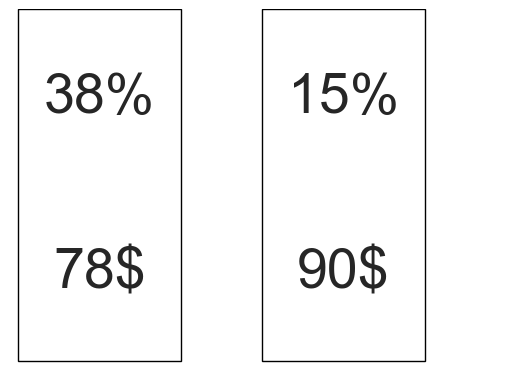

dEV: 6.16


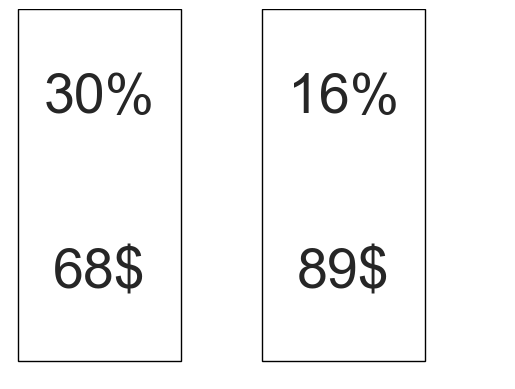

dEV: 0.58


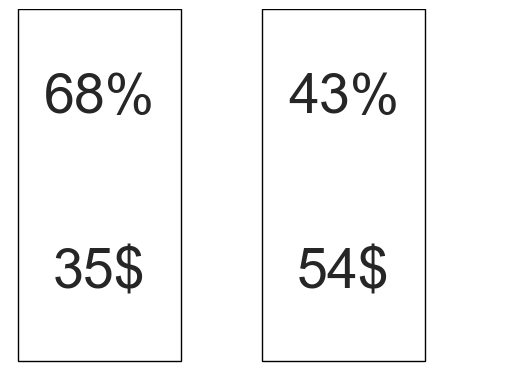

dEV: -25.11


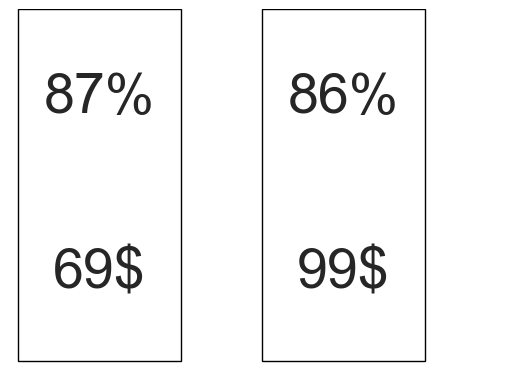

dEV: -3.09


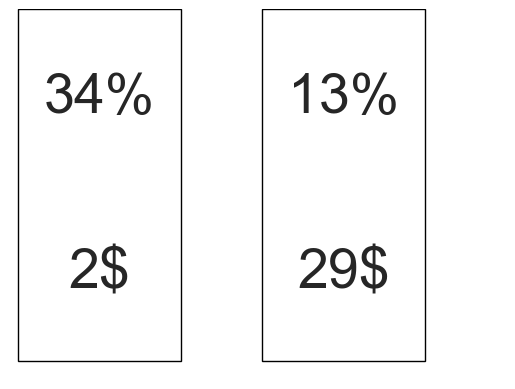

dEV: 4.94


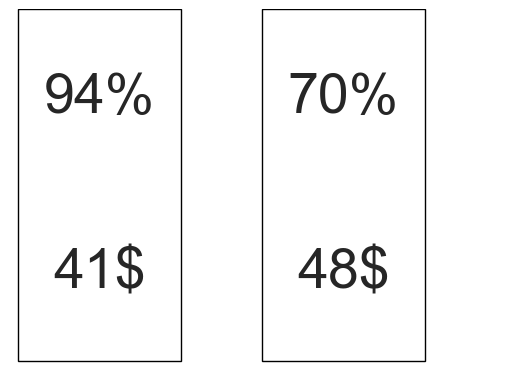

dEV: 5.58


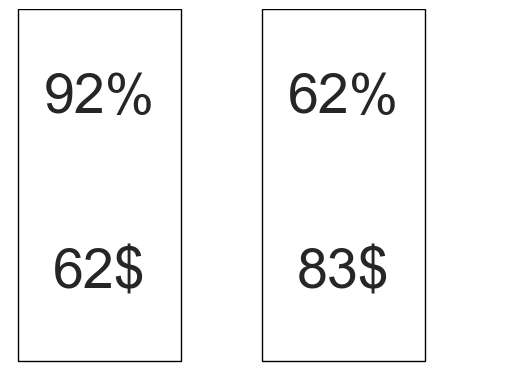

dEV: 0.69


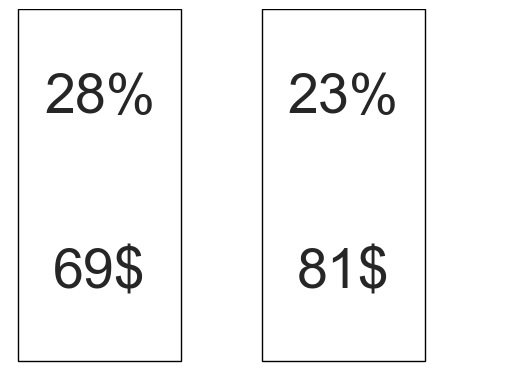

dEV: -0.32


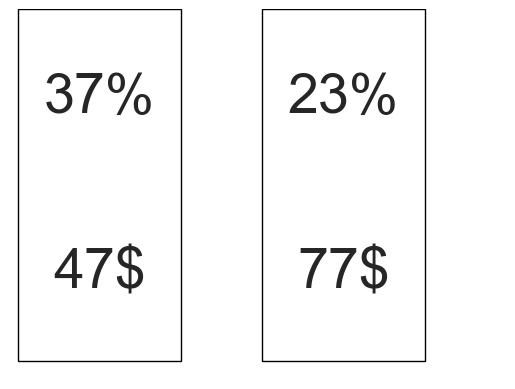

dEV: -1.01


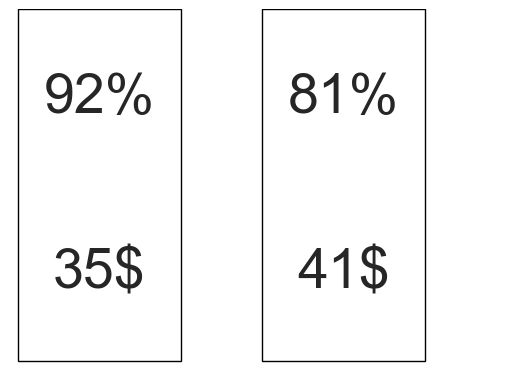

dEV: 8.18


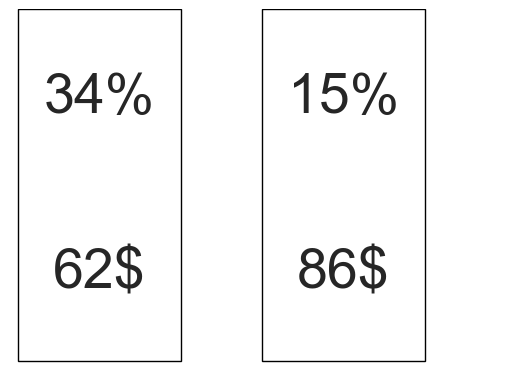

dEV: -21.08


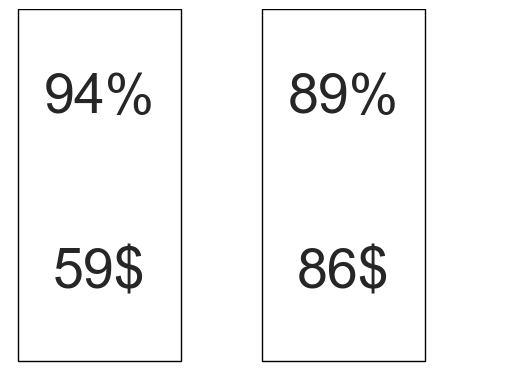

dEV: -6.00


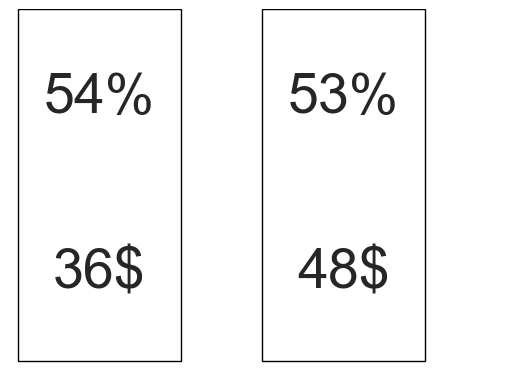

dEV: -3.38


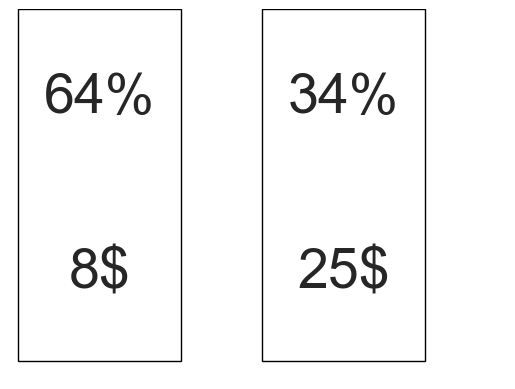

dEV: -17.94


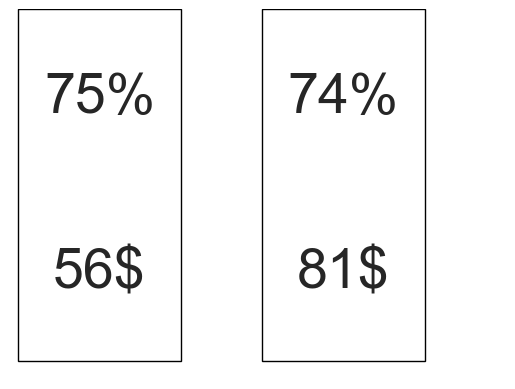

In [39]:
# Gamble visualization

for i in  range(n_trials):
    selected_gamble = df_gambles[df_gambles['GambleNumber']==i+1]
    
    lot_0_val = selected_gamble['lot_0_val'].iloc[0] 
    lot_0_prob = selected_gamble['lot_0_prob'].iloc[0] 
    lot_1_val = selected_gamble['lot_1_val'].iloc[0] 
    lot_1_prob = selected_gamble['lot_1_prob'].iloc[0]

    print(f"dEV: {selected_gamble['dEV'].iloc[0]:.2f}")
    
    VisualizeGamble(lot_0_val, lot_0_prob, lot_1_val, lot_1_prob)

## Save Experiment Trials

In [40]:

path_to_folder = "../static/gambles"

gambles_file = f'{path_to_folder}/gambles.csv'
df_gambles.to_csv(gambles_file, index=False)

## Generate practice trials

In [36]:
array = np.array([[1, 60,50,30, 30,20,6, 30,30,24, 0, 8], 
                  [2, 40,50,20, 75,24,18, -35,26,2, 1, 10,], 
                  [3, 3,6,0.18, 9,2,0.18, -6,4,0, 1, 12],
                  [4, 40,80,32, 90,10,9, -50,70,23, 1, 10], 
                  [5, 10,90,9, 20,45,9, -10,45,0, 1, 8], 
                  [6, 80,90,72, 20,1,2, 60,89,70, 0, 12]])

## Save practice trials

In [37]:
column_names = ["PracticeGambleNumber",
                "lot_0_val",
                "lot_0_prob",
                "lot_0_ev",
                "lot_1_val",
                "lot_1_prob",
                "lot_1_ev",
                "dX",
                "dP",
                "dEV",
                "Deadline"]

In [38]:
practice_gambles_df = pd.DataFrame(array, columns = column_names)

ValueError: Shape of passed values is (6, 12), indices imply (6, 11)

In [ ]:
path_to_folder = r'../static'

In [ ]:
practice_gambles_file = f'{path_to_folder}/practice_gambles.csv'
practice_gambles_df.to_csv(practice_gambles_file, index=False)